In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix,roc_curve, roc_auc_score
%matplotlib inline

<h2>Notebook to classify whether the tomato leaf images are diseased or not, based on glcm features</h2>

In [152]:
#read detection dataframe
df=pd.read_csv("Data/train_detection.csv")
df.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,1
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,1
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,1
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,1
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,1


In [113]:
#extract the target feature
y=df['class']
X=df.drop(labels="class",axis=1)
y.head()

0    1
1    1
2    1
3    1
4    1
Name: class, dtype: int64

In [114]:
X.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


In [115]:
#divide data into training and validation data
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,stratify=df['class'],random_state=1)#equal classes in train and test
X_train.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
58,1.465746,0.054413,0.918084,0.918084,108.015921,11.264020,0.021992,0.957068,0.175747,0.992297,...,1.459526,2.154929,5.262959,0.157612,0.054413,0.085227,-0.675361,0.404961,0.997853,0.999300
74,2.623449,0.226382,0.890990,0.890990,228.996836,27.330417,0.094645,0.795433,0.689470,0.966033,...,2.696156,2.606579,7.944549,0.601935,0.226382,0.284599,-0.614711,0.676252,0.990690,0.997072
90,4.602481,0.274810,0.881824,0.881824,38.152597,5.857354,0.225882,0.317922,1.692087,0.894599,...,4.682211,3.782739,9.693653,1.476651,0.274810,0.575996,-0.573978,0.862245,0.975430,0.995857
35,1.500289,0.099062,0.856669,0.856669,67.960771,8.949488,0.039946,0.934587,0.248797,0.986619,...,1.515769,2.194867,5.186308,0.219136,0.099062,0.134356,-0.580040,0.428558,0.996126,0.998684
86,7.639327,0.281553,0.942850,0.942850,137.504610,14.544878,0.219284,0.344013,1.672913,0.899347,...,7.713375,4.611758,19.501714,1.460382,0.281553,0.568176,-0.606605,0.875840,0.976291,0.995798


<h2>Feature Normalization</h2>

In [116]:
scaler=StandardScaler()
columns=X_train.columns
X_train=pd.DataFrame(scaler.fit_transform(X_train),columns=columns)
X_val=pd.DataFrame(scaler.transform(X_val),columns=columns)
X_train.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,-1.078776,-1.696374,0.521909,0.521909,-0.855082,-0.937949,-1.527562,1.345081,-1.455971,1.406307,...,-1.100481,-1.126131,-1.041553,-1.448645,-1.696374,-1.746092,-1.951017,-2.021607,1.485544,1.694720
1,-0.686131,-0.416382,-0.135460,-0.135460,0.646018,0.687758,-0.760177,0.705684,-0.663910,0.802771,...,-0.684981,-0.718377,-0.648903,-0.646654,-0.416382,-0.741448,-0.829829,-0.241237,0.786286,0.549540
2,-0.014924,-0.055927,-0.357847,-0.357847,-1.721928,-1.485033,0.625990,-1.183266,0.881931,-0.838781,...,-0.017678,0.343473,-0.392792,0.932186,-0.055927,0.726917,-0.076853,0.979360,-0.703362,-0.074681
3,-1.067061,-1.364048,-0.968168,-0.968168,-1.352076,-1.172150,-1.337921,1.256151,-1.343342,1.275817,...,-1.081584,-1.090075,-1.052776,-1.337595,-1.364048,-1.498532,-0.188902,-1.866747,1.316931,1.378101
4,1.015050,-0.005733,1.122783,1.122783,-0.489194,-0.605970,0.556298,-1.080052,0.852369,-0.729683,...,1.000775,1.091919,1.043344,0.902819,-0.005733,0.687513,-0.679983,1.068580,-0.619337,-0.105032


In [117]:
print(y_train.value_counts())
print(y_val.value_counts())
y_train.head()

1    64
0    32
Name: class, dtype: int64
1    16
0     8
Name: class, dtype: int64


58    1
74    1
90    0
35    1
86    0
Name: class, dtype: int64

In [118]:
#choosing different C values
C=[0.01,0.03,0.1,0.3,1,3,10,30,100]
sigma=[0.01,0.03,0.1,0.3,1,3,10,30,100]


In [119]:
#predict score function
def predict_score(x_test,y_test,x_train,y_train,C,sigma):
    model=SVC(C=C,kernel='rbf',gamma=sigma)
    model.fit(x_train,y_train)
    predictions=model.predict(x_test)
    print(">>>>>>>")
    print("Accuracy: C={} sigma={} is {}".format(C,sigma,metrics.accuracy_score(y_test,predictions)))
    print(">>>>>>>")
    
    
    

<h2>Hyperparameters</h2>

In [120]:
parameters={'C':C,'gamma':sigma,'kernel':['rbf']}
cols=X.columns
X=pd.DataFrame(scaler.fit_transform(X),columns=cols)
X.describe().apply(lambda s: s.apply('{0:.5f}'.format))


,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
count,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,...,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000
mean,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,0.00000,...,-0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000
std,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,...,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419
min,-1.10782,-1.71325,-3.25142,-3.25142,-1.85066,-1.88742,-1.45906,-1.63607,-1.39430,-1.92654,...,-1.12825,-1.11484,-1.14304,-1.38843,-1.71325,-1.66166,-2.71528,-2.16523,-1.95276,-2.30449
25%,-0.84141,-0.72594,-0.71643,-0.71643,-0.71068,-0.73506,-0.88587,-1.18085,-0.93072,-0.91649,...,-0.84597,-0.86967,-0.81486,-0.92665,-0.72594,-0.91464,-0.62578,-0.85113,-0.84385,-0.78033
50%,-0.49025,-0.03014,0.29667,0.29667,-0.12936,-0.17730,-0.20096,0.33584,-0.29086,0.27402,...,-0.47507,-0.48426,-0.46897,-0.30061,-0.03014,-0.05804,0.11575,0.01612,0.22050,0.04977
75%,0.94049,0.73300,0.74875,0.74875,0.63854,0.56298,0.82877,0.93264,1.03107,0.91376,...,0.92337,1.07730,0.81028,1.06398,0.73300,0.89910,0.73559,1.11472,0.89683,0.75780
max,2.52279,2.59675,1.59095,1.59095,3.58591,3.39018,1.95489,1.28409,1.78031,1.34333,...,2.49454,2.10580,3.11322,1.74849,2.59675,1.67822,2.55872,1.27789,1.41853,1.66159


In [121]:
grid_s=GridSearchCV(SVC(),parameters,refit=True,verbose=3)
grid_s.fit(X,y)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV 1/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.667 total time=   0.0s
[CV 2/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.667 total time=   0.0s
[CV 3/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.667 total time=   0.0s
[CV 4/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.667 total time=   0.0s
[CV 5/5] END ....C=0.01, gamma=0.01, kernel=rbf;, score=0.667 total time=   0.0s
[CV 1/5] END ....C=0.01, gamma=0.03, kernel=rbf;, score=0.667 total time=   0.0s
[CV 2/5] END ....C=0.01, gamma=0.03, kernel=rbf;, score=0.667 total time=   0.0s
[CV 3/5] END ....C=0.01, gamma=0.03, kernel=rbf;, score=0.667 total time=   0.0s
[CV 4/5] END ....C=0.01, gamma=0.03, kernel=rbf;, score=0.667 total time=   0.0s
[CV 5/5] END ....C=0.01, gamma=0.03, kernel=rbf;, score=0.667 total time=   0.0s
[CV 1/5] END .....C=0.01, gamma=0.1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 2/5] END .....C=0.01, gamma=0.1, kernel=rbf

[CV 1/5] END ......C=0.1, gamma=0.3, kernel=rbf;, score=0.792 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.3, kernel=rbf;, score=0.792 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.3, kernel=rbf;, score=0.750 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.3, kernel=rbf;, score=0.875 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.3, kernel=rbf;, score=0.792 total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=3, kernel=rbf;, score=0.667 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=3, kernel=rbf;, score=0.667 total time=   0.0s
[CV 3/5] END ........C=0.1, 

[CV 5/5] END .........C=1, gamma=10, kernel=rbf;, score=0.667 total time=   0.0s
[CV 1/5] END .........C=1, gamma=30, kernel=rbf;, score=0.667 total time=   0.0s
[CV 2/5] END .........C=1, gamma=30, kernel=rbf;, score=0.667 total time=   0.0s
[CV 3/5] END .........C=1, gamma=30, kernel=rbf;, score=0.667 total time=   0.0s
[CV 4/5] END .........C=1, gamma=30, kernel=rbf;, score=0.667 total time=   0.0s
[CV 5/5] END .........C=1, gamma=30, kernel=rbf;, score=0.667 total time=   0.0s
[CV 1/5] END ........C=1, gamma=100, kernel=rbf;, score=0.667 total time=   0.0s
[CV 2/5] END ........C=1, gamma=100, kernel=rbf;, score=0.667 total time=   0.0s
[CV 3/5] END ........C=1, gamma=100, kernel=rbf;, score=0.667 total time=   0.0s
[CV 4/5] END ........C=1, gamma=100, kernel=rbf;, score=0.667 total time=   0.0s
[CV 5/5] END ........C=1, gamma=100, kernel=rbf;, score=0.667 total time=   0.0s
[CV 1/5] END .......C=3, gamma=0.01, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END .......C=3, gam

[CV 2/5] END ......C=30, gamma=0.03, kernel=rbf;, score=1.000 total time=   0.0s
[CV 3/5] END ......C=30, gamma=0.03, kernel=rbf;, score=1.000 total time=   0.0s
[CV 4/5] END ......C=30, gamma=0.03, kernel=rbf;, score=1.000 total time=   0.0s
[CV 5/5] END ......C=30, gamma=0.03, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/5] END .......C=30, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END .......C=30, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 3/5] END .......C=30, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 4/5] END .......C=30, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 5/5] END .......C=30, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/5] END .......C=30, gamma=0.3, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END .......C=30, gamma=0.3, kernel=rbf;, score=0.958 total time=   0.0s
[CV 3/5] END .......C=30, gamma=0.3, kernel=rbf;, score=0.958 total time=   0.0s
[CV 4/5] END .......C=30, ga

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'gamma': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'kernel': ['rbf']},
             verbose=3)

In [122]:
print(grid_s.best_params_)
print(grid_s.best_estimator_)

{'C': 0.3, 'gamma': 0.03, 'kernel': 'rbf'}
SVC(C=0.3, gamma=0.03)


In [123]:
#best c=0.3 , best gamma for this classification=0.03
model=SVC(C=0.3,gamma=0.03,kernel='rbf')
model.fit(X,y)

SVC(C=0.3, gamma=0.03)

<h2> Predictions</h2>

In [124]:
test_data=pd.read_csv('./Data/test_detection.csv')
test_data.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,1
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,1
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,1
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,1
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,1


In [125]:
test_data.describe()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
count,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,...,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,4.573637,0.268571,0.896885,0.896885,177.143063,19.952697,0.159041,0.632742,1.080797,0.934148,...,3.362680,12.227574,0.927930,0.268571,0.415215,-0.573578,0.704298,0.983417,0.996195,0.682292
std,3.147084,0.135100,0.043796,0.043796,81.769198,9.804233,0.097084,0.257692,0.665400,0.044638,...,1.167284,7.299367,0.568358,0.135100,0.201610,0.054625,0.152985,0.010510,0.001968,0.466803
min,1.192696,0.038599,0.758959,0.758959,19.710267,-7.483682,0.018399,0.191741,0.138469,0.844161,...,2.082085,4.293570,0.123163,0.038599,0.075501,-0.718767,0.331383,0.961323,0.991679,0.000000
25%,2.105185,0.160458,0.865038,0.865038,118.120970,12.942858,0.072317,0.315043,0.493837,0.892566,...,2.426678,6.620598,0.427745,0.160458,0.230502,-0.610384,0.583406,0.974446,0.994640,0.000000
50%,3.055012,0.262109,0.912535,0.912535,170.426233,18.764016,0.137972,0.716502,0.895940,0.948060,...,2.804838,8.886739,0.767411,0.262109,0.392671,-0.567283,0.706412,0.985968,0.996326,1.000000
75%,7.483346,0.370147,0.930238,0.930238,229.559781,25.492773,0.240104,0.858719,1.784732,0.973690,...,4.613299,18.068471,1.552272,0.370147,0.600653,-0.534954,0.880958,0.992765,0.997839,1.000000
max,14.311495,0.618669,0.964613,0.964613,483.040290,54.566770,0.366055,0.966052,2.270148,0.993272,...,6.557724,36.534593,1.927983,0.618669,0.787256,-0.435715,0.906791,0.998155,0.999467,1.000000


In [126]:
y_test=test_data['class']
print(y_test.value_counts())
y_test.head()

1    131
0     61
Name: class, dtype: int64


0    1
1    1
2    1
3    1
4    1
Name: class, dtype: int64

In [127]:
X_test=test_data.drop(labels="class",axis=1)
print(X_test.shape)
X_test.head()

(192, 22)


,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


In [128]:
#making predictions
cols=X_test.columns
X_test=pd.DataFrame(scaler.fit_transform(X_test),columns=cols)
predictions=model.predict(X_test)
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00       131

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192



<h2>Confusion Matrix</h2>

<AxesSubplot:>

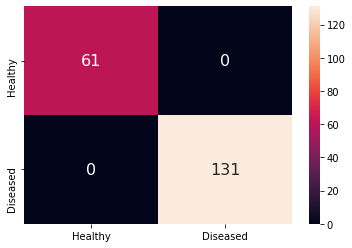

In [141]:
matrix=confusion_matrix(y_test,predictions)
cm_df=pd.DataFrame(matrix,index=["Healthy","Diseased"],columns=["Healthy","Diseased"])
plt.xlabel("")
sns.heatmap(cm_df,annot_kws={"size": 16},annot=True,fmt="d")

<h2>ROC Curve</h2>

In [149]:
fp_rate,tp_rate,threshold=roc_curve(y_test,predictions)
print("roc auc score is : {}".format(roc_auc_score(y_test,predictions)))


roc auc score is : 1.0


Text(0.5, 0, 'False positive rate')

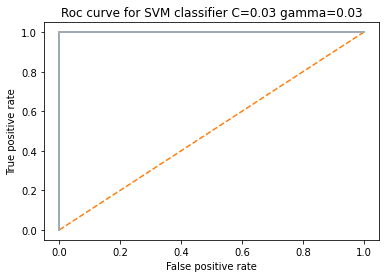

In [150]:
plt.title('Roc curve for SVM classifier C=0.03 gamma=0.03')
plt.plot(fp_rate,tp_rate)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7")
plt.plot([1, 1] , c=".7")
plt.ylabel("True positive rate")
plt.xlabel("False positive rate")